# Part 3 : Arbres de Décision & Random Forest

**Durée estimée : 2h30**

## 🎯 Objectifs d'apprentissage

À la fin de cette partie, vous serez capable de :
1. **Expliquer** l'intuition d'un arbre de décision (série de questions if/else)
2. **Visualiser** et interpréter un arbre de décision
3. **Identifier** le problème de l'overfitting avec les arbres
4. **Appliquer** Random Forest pour obtenir des prédictions plus robustes
5. **Analyser** l'importance des features

---

## 🌍 Problème Réel : Comment une banque décide-t-elle de vous accorder un prêt ?

Vous faites une demande de crédit immobilier. En quelques jours (parfois quelques minutes en ligne !), la banque vous donne sa réponse : **approuvé** ou **refusé**.

**Question :** Comment la banque peut-elle évaluer si vous allez rembourser ou faire défaut ?

*(Prenez 30 secondes pour réfléchir...)*

<details>
<summary>🤔 Votre intuition ?</summary>

### 🔑 Réponse

La banque pose une série de **questions** sur votre profil :
- Quel est votre revenu ?
- Avez-vous un emploi stable ?
- Quel est votre historique de crédit ?
- Avez-vous d'autres dettes ?

Selon les réponses, elle suit un **arbre de décision** interne.

C'est exactement ce que fait un **arbre de décision** en Machine Learning : une série de questions qui mènent à une décision.

</details>

### Le scoring crédit : un cas d'étude réel

Selon une [étude 2024 publiée dans Engineering Reports](https://onlinelibrary.wiley.com/doi/10.1002/eng2.12707), l'algorithme Random Forest atteint **91% de précision** dans la prédiction d'approbation de prêt, contre 83% pour un arbre de décision simple.

Une autre [étude de 2024](https://dl.acm.org/doi/10.1145/3708036.3708173) utilise Random Forest pour évaluer le risque de crédit dans les plateformes de prêt en ligne, aidant à prédire les tendances de défaut de paiement.

| Facteur analysé | Impact sur la décision |
|-----------------|------------------------|
| Historique de crédit | Très fort |
| Ratio dette/revenu | Fort |
| Durée d'emploi | Moyen |
| Montant du prêt demandé | Moyen |
| Statut marital | Faible |

---

## 3.1 L'Arbre de Décision : Une Série de Questions

Imaginez le processus de décision d'un banquier simplifié :

```
┌───────────────────────────────────────────────────────────────────────┐
│              ARBRE DE DÉCISION : Approuver un prêt ?                  │
├───────────────────────────────────────────────────────────────────────┤
│                                                                       │
│                    ┌─────────────────────┐                            │
│                    │ Revenu > 35 000€/an │                            │
│                    └──────────┬──────────┘                            │
│                       OUI /        \ NON                              │
│                          /          \                                 │
│           ┌──────────────┐          ┌──────────────┐                  │
│           │ Historique   │          │ Co-emprunteur│                  │
│           │ crédit bon ? │          │ disponible ? │                  │
│           └──────┬───────┘          └──────┬───────┘                  │
│            OUI /   \ NON             OUI /   \ NON                    │
│               /     \                   /     \                       │
│       ┌──────┐    ┌──────┐      ┌──────┐    ┌──────┐                  │
│       │  ✅  │    │Ratio │      │  ✅  │    │  ❌  │                  │
│       │APPROUV│   │dette?│      │APPROUV│   │REFUSÉ│                  │
│       └──────┘    └──┬───┘      └──────┘    └──────┘                  │
│                  <30% / ≥30%                                          │
│                     /    \                                            │
│              ┌──────┐  ┌──────┐                                       │
│              │  ✅  │  │  ❌  │                                       │
│              │APPROUV│  │REFUSÉ│                                       │
│              └──────┘  └──────┘                                       │
│                                                                       │
└───────────────────────────────────────────────────────────────────────┘
```

**Question Socratique :** Pourquoi cet arbre est-il facile à comprendre pour un humain, comparé aux coefficients de la régression logistique ?

*(Réponse attendue : On peut suivre le raisonnement pas à pas. C'est comme une succession de règles métier claires. On peut même expliquer à un client pourquoi son prêt a été refusé.)*

Un arbre de décision est une structure arborescente semblable à un organigramme dans  laquelle un nœud interne représente une caractéristique (ou un attribut), la branche    représente une règle de décision et chaque nœud feuille représente le résultat.        
                                                                                       
Le nœud le plus élevé dans un arbre de décision est appelé nœud racine.                

---

## 3.2 Comment l'Arbre Construit ses Questions

Maintenant que nous avons vu à quoi ressemble un arbre, comprenons comment l'algorithme **décide** quelles questions poser et dans quel ordre.

### Le problème : des centaines de questions possibles

Imaginez que vous êtes l'algorithme. Vous avez 5 features :
- Revenu (valeurs de 20 000 à 100 000)
- Historique crédit (bon/mauvais)
- Ratio dette (0% à 60%)
- Ancienneté emploi (0 à 20 ans)
- Montant prêt (5 000 à 50 000)

Pour la première question, vous pourriez demander :
- "Revenu > 30 000 ?" ou "Revenu > 40 000 ?" ou "Revenu > 50 000 ?"...
- "Historique crédit = bon ?"
- "Ratio dette > 20% ?" ou "Ratio dette > 30% ?"...
- Et ainsi de suite...

→ **Des centaines de questions possibles !** Comment choisir la meilleure ?

### L'analogie des billes

Imaginez un sac contenant des billes de deux couleurs : 🔴 (refusé) et 🟢 (approuvé).

```
┌─────────────────────────────────────────────────────────────────────┐
│     L'ANALOGIE DES BILLES : TROUVER LA MEILLEURE QUESTION          │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Sac initial : 🔴🔴🔴🟢🟢🔴🟢🔴🟢🟢  (mélangé)                       │
│                                                                     │
│  Question A : "Revenu > 40 000 ?"                                   │
│  ┌─────────────────┐     ┌─────────────────┐                        │
│  │ OUI             │     │ NON             │                        │
│  │ 🟢🟢🟢🟢🔴       │     │ 🔴🔴🔴🔴🟢       │                        │
│  │ (80% vert)      │     │ (80% rouge)     │                        │
│  └─────────────────┘     └─────────────────┘                        │
│  → BONNE séparation ! Les groupes sont assez "purs"                │
│                                                                     │
│  Question B : "Statut marital = célibataire ?"                      │
│  ┌─────────────────┐     ┌─────────────────┐                        │
│  │ OUI             │     │ NON             │                        │
│  │ 🔴🟢🔴🟢🔴       │     │ 🟢🔴🟢🔴🟢       │                        │
│  │ (50% chaque)    │     │ (50% chaque)    │                        │
│  └─────────────────┘     └─────────────────┘                        │
│  → MAUVAISE séparation ! Les groupes restent mélangés              │
│                                                                     │
│  L'arbre choisit la Question A car elle crée des groupes plus PURS │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

Imaginez que vous devez trier des demandes de prêt en deux piles. Quelle question unique permettrait de faire le tri le plus efficace dès le départ ?

- Si vous demandez "Revenu > 35 000€ ?" → vous séparez probablement bien les approuvés des refusés
- Si vous demandez "Statut marital ?" → ça ne sépare probablement pas grand-chose

L'arbre cherche toujours la question qui crée les groupes les plus **"purs"** (le plus homogènes possible).

**Question :** Comment mesurer à quel point un groupe est "pur" ou "mélangé" ?

*(Réponse attendue : On pourrait compter le pourcentage de chaque couleur. Un groupe 100% d'une couleur = pur. Un groupe 50/50 = très mélangé.)*



### Le critère de Gini : mesurer l'impureté

L'**indice de Gini** mesure à quel point un groupe est mélangé :

```
┌───────────────────────────────────────────────────────────────┐
│                    INDICE DE GINI                             │
├───────────────────────────────────────────────────────────────┤
│                                                               │
│  Gini = 0          Groupe "pur"                               │
│  ●●●●●●●●●●        (tous de la même classe)                   │
│                                                               │
│  Gini = 0.5        Groupe "mélangé"                           │
│  ●●●●●○○○○○        (50% de chaque classe)                     │
│                                                               │
│  L'arbre cherche à MINIMISER le Gini après chaque split       │
│                                                               │
└───────────────────────────────────────────────────────────────┘
```

### Le processus de construction

1. **Pour chaque feature**, tester toutes les valeurs de seuil possibles
2. **Calculer le Gini** résultant après le split
3. **Choisir le split** qui minimise le Gini (crée les groupes les plus purs)
4. **Répéter** sur chaque sous-groupe jusqu'à ce que :
   - Les groupes soient purs (Gini = 0)
   - Ou qu'on atteigne une limite (profondeur max, min samples, etc.)

## 3.3 Création d'un arbre de décision

### Comment lire un noeud d'arbre de décision (sklearn)

```
┌───────────────────────────────────────────────────────────────────────┐
│     ANATOMIE D'UN NŒUD SKLEARN                                        │
├───────────────────────────────────────────────────────────────────────┤
│                                                                       │
│           ┌─────────────────────────────┐                             │
│           │  revenu <= 40000.0          │  ← LA QUESTION posée        │
│           │  gini = 0.48                │  ← Pureté (0=pur, 0.5=mélangé)│
│           │  samples = 400              │  ← Combien d'exemples ici   │
│           │  value = [180, 220]         │  ← [Refusé, Approuvé]       │
│           │  class = Approuvé           │  ← Prédiction majoritaire   │
│           └─────────────────────────────┘                             │
│                                                                       │
│  La COULEUR indique la classe dominante :                             │
│  • Orange/Rouge → une classe                                          │
│  • Bleu → l'autre classe                                              │
│  • Plus la couleur est INTENSE → plus le groupe est pur               │
│                                                                       │
└───────────────────────────────────────────────────────────────────────┘
```

**Question :** Si un nœud a `gini = 0.0`, que pouvez-vous en déduire ?

*(Réponse attendue : Tous les exemples de ce nœud appartiennent à la même classe. C'est un groupe "pur" — l'arbre n'a plus besoin de poser d'autres questions pour ce groupe.)*

---

Maintenant, voyons un arbre construit sur de vraies données !

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# Créer un dataset de prêts simplifié
np.random.seed(42)
n = 500

data = pd.DataFrame({
    'revenu': np.random.uniform(20000, 100000, n),
    'historique_credit': np.random.choice([0, 1], n, p=[0.3, 0.7]),  # 0=mauvais, 1=bon
    'ratio_dette': np.random.uniform(0, 0.6, n),
    'anciennete_emploi': np.random.uniform(0, 20, n),  # années
    'montant_pret': np.random.uniform(5000, 50000, n)
})

# Générer la cible (approuvé/refusé) selon des règles
data['approuve'] = (
    (data['revenu'] > 40000) & 
    (data['historique_credit'] == 1) & 
    (data['ratio_dette'] < 0.4)
).astype(int)

# Ajouter du bruit
flip_idx = np.random.choice(n, size=int(n*0.1), replace=False)
data.loc[flip_idx, 'approuve'] = 1 - data.loc[flip_idx, 'approuve']

print("Aperçu des données :")
display(data.head(10))
print(f"\nDistribution : {data['approuve'].value_counts().to_dict()}")

Aperçu des données :


,revenu,historique_credit,ratio_dette,anciennete_emploi,montant_pret,approuve
0,49963.209508,1,0.111080,10.381636,16776.755768,1
1,96057.144513,1,0.325141,9.583638,16114.045958,1
2,78559.515345,1,0.523768,0.512841,45781.456123,0
3,67892.678736,1,0.439335,6.824957,16229.578993,0
4,32481.491235,1,0.483937,7.603912,17237.737676,0
5,32479.561627,0,0.395270,7.976456,39172.921809,0
6,24646.688973,1,0.415366,11.603447,25238.292910,0
7,89294.091662,1,0.509517,10.672051,39951.975063,0
8,68089.200939,1,0.149801,12.158102,7941.477090,1
9,76645.806224,1,0.293655,15.297665,26940.703715,1



Distribution : {0: 306, 1: 194}


In [23]:
# Entraîner un arbre de décision simple
X = data.drop('approuve', axis=1)
y = data['approuve']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Arbre avec profondeur limitée pour la lisibilité
dtc = DecisionTreeClassifier(max_depth=3, random_state=42)
dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [27]:
#Predict the response for test dataset
y_pred = dtc.predict(X_test)

dtc# Model Accuracy, how often is the classifier correct?
print("Accuracy sur le test :",dtc.score(X_test, y_test))
print("Accuracy:",dtc.score(X_test, y_test))


Accuracy: 0.85


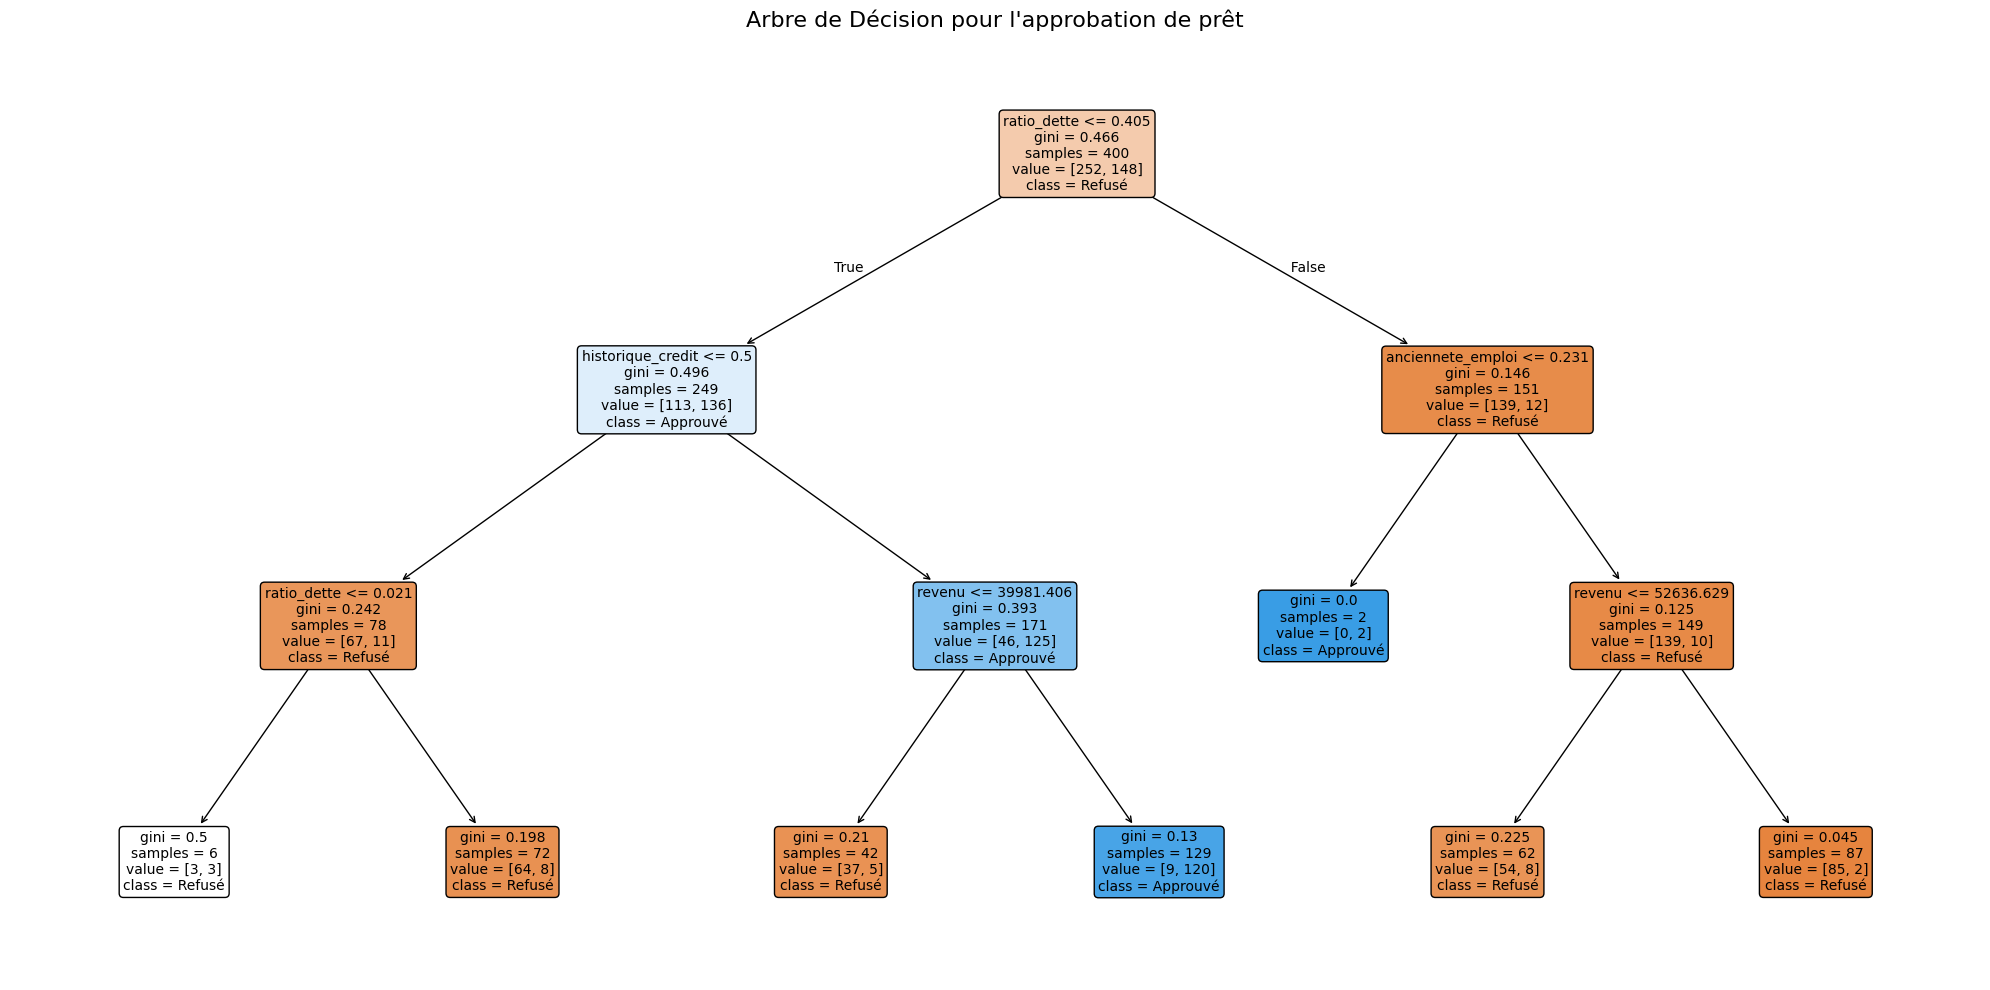

In [28]:
# Visualiser l'arbre
plt.figure(figsize=(20, 10))
plot_tree(dtc, 
          feature_names=X.columns, 
          class_names=['Refusé', 'Approuvé'],
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Arbre de Décision pour l\'approbation de prêt', fontsize=16)
plt.tight_layout()
plt.show()

### Analayse de l'arbre

1. La Structure Globale : "Un jeu de questions"

* Tout en haut (**la Racine**), on a tous les dossiers de demande de prêt (400 dossiers).
* L'arbre pose une question.
* Si la réponse est **VRAI (True)**, on part à gauche.
* Si la réponse est **FAUX (False)**, on part à droite.
* Le but est de séparer les dossiers "Refusés" (Orange) des "Approuvés" (Bleu).

2. Anatomie d'une Boîte (Le Nœud)

Prenons la boîte tout en haut (la racine) pour décrypter le langage technique :

* **`ratio_dette <= 0.405`** : C'est la **Question**. Le modèle a calculé que le critère le plus discriminant pour accorder un prêt est le ratio de dette.
* *Seuil de 0.405* : Si votre dette dépasse 40.5% de vos revenus, vous partez à droite (False).

* **`gini = 0.466`** : C'est l'indice d'**Impureté**.
* *Gini = 0* : Le groupe est pur (tout le monde a le même statut).
* *Gini = 0.5* : C'est le mélange total (50/50).
* Ici, 0.466 signifie que c'est assez mélangé, on a des dossiers refusés et acceptés.

* **`samples = 400`** : Le nombre total de dossiers présents dans cette boîte.

* **`value = [252, 148]`** : La répartition réelle.
* 252 Refusés (Index 0).
* 148 Approuvés (Index 1).

* **`class = Refusé`** : La décision majoritaire. Comme il y a plus de refusés (252) que d'approuvés (148), par défaut, cette boîte est classée "Refusé" (d'où la couleur orange clair).

3. L'Histoire que raconte l'arbre (Analyse Métier)

Suivons les chemins pour comprendre la logique de la banque :

**Chemin A : Les dossiers risqués (À droite)**

1. **Question :** Est-ce que le ratio de dette est faible () ?
2. **Réponse :** NON (False). Donc le ratio est élevé.
3. **Résultat (Boîte orange foncée à droite) :**
* Regardez la couleur **Orange foncé** : C'est un signe de certitude !
* Le `gini` chute à **0.146** (c'est très pur).
* Sur 151 personnes avec beaucoup de dettes, **139 sont refusées** et seulement 12 approuvées.
* *Conclusion :* Si tu as trop de dettes, le modèle te refuse quasi-automatiquement. Il tente ensuite une subdivision sur `anciennete_emploi` (mais la masse est déjà jouée).


**Chemin B : Les dossiers potentiels (À gauche)**

1. **Question :** Est-ce que le ratio de dette est faible () ?
2. **Réponse :** OUI (True).
3. **Résultat (Boîte bleue à gauche) :**
* La couleur change ! Elle devient **Bleue**.
* Pourquoi ? Regardez `value = [113, 136]`. Les "Approuvés" (136) passent devant les "Refusés" (113).
* Mais attention, le `gini` est de **0.496**. C'est très impur ! Le match est serré.
* Le modèle doit donc poser une **deuxième question** pour affiner : **`historique_credit <= 0.5`**.


> "Cet arbre nous apprend que le **Ratio de Dette** est le critère roi. S'il est mauvais (branche de droite), c'est le refus quasi immédiat (orange foncé). S'il est bon (branche de gauche), rien n'est encore gagné (bleu pâle), il faut ensuite regarder l'historique de crédit pour trancher."

---

## 3.4 Le Problème de l'Overfitting

Ici, l'arbre résultant n'est pas élagué. Cet arbre non taillé est difficile à expliquer et à comprendre. Dans la section suivante, nous allons l'optimiser par élagage.

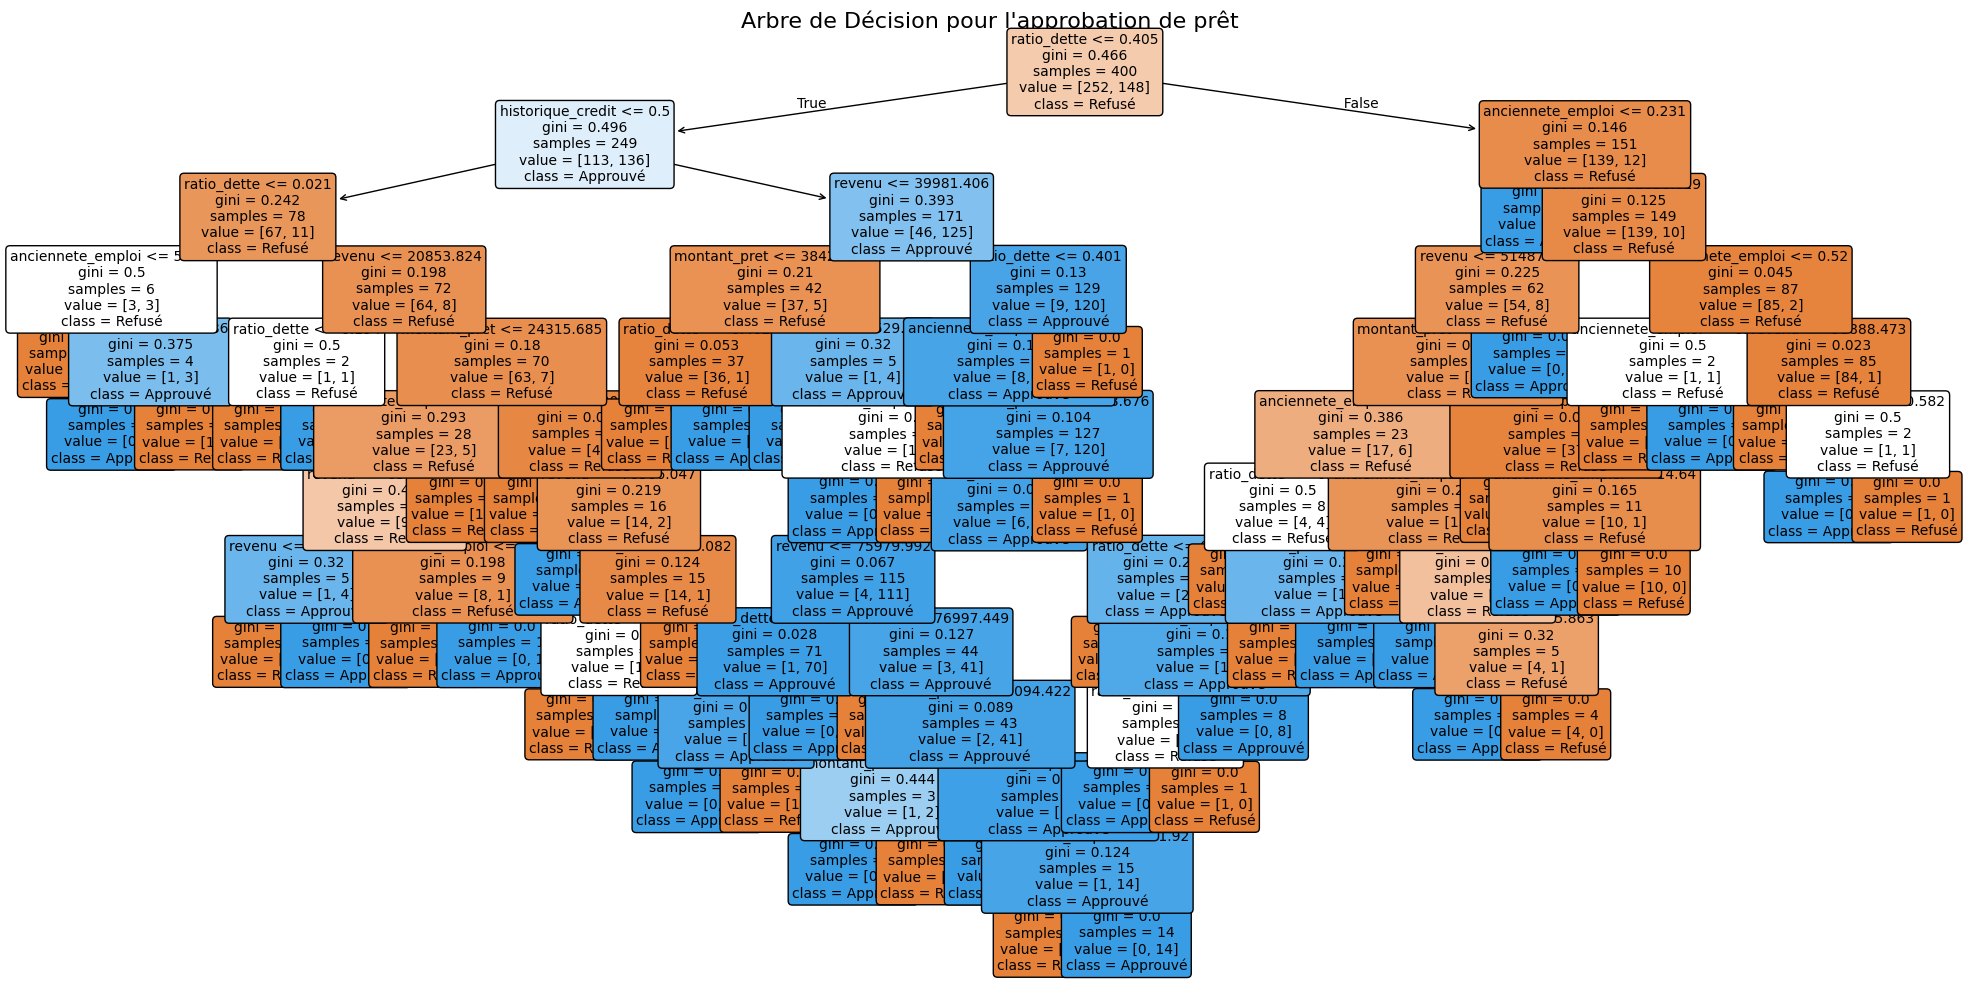

In [30]:
# Arbre avec profondeur ilimitée pour la lisibilité
dtc_ilimite = DecisionTreeClassifier()
dtc_ilimite.fit(X_train, y_train)
# Visualiser l'arbre
plt.figure(figsize=(20, 10))
plot_tree(dtc_ilimite, 
          feature_names=X.columns, 
          class_names=['Refusé', 'Approuvé'],
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Arbre de Décision pour l\'approbation de prêt', fontsize=16)
plt.tight_layout()
plt.show()


**Question Socratique :** Que se passe-t-il si on laisse l'arbre grandir sans limite ?

*(Réponse attendue : L'arbre va créer des règles très spécifiques pour chaque exemple d'entraînement. Il va "mémoriser" les données au lieu d'apprendre des patterns généraux.)*

### Comparer un arbre simple vs un arbre profond

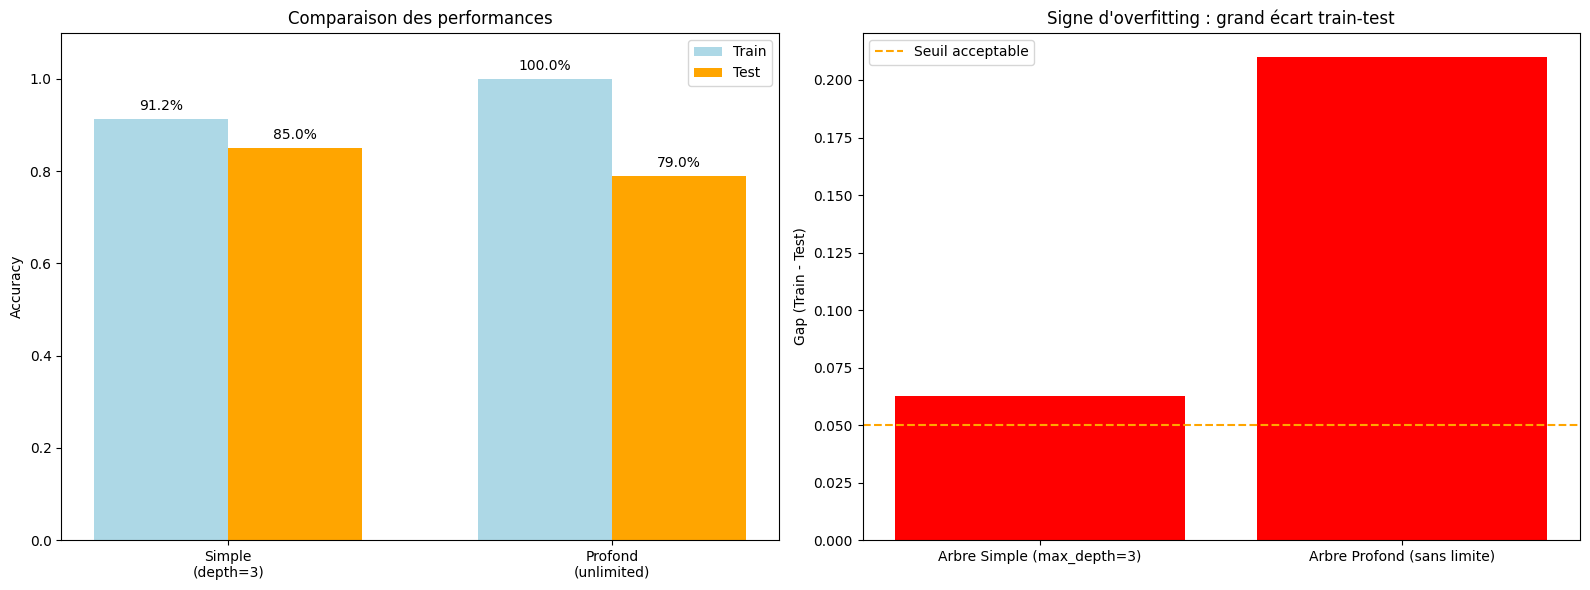


════════════════════════════════════════════════════════════
DIAGNOSTIC
════════════════════════════════════════════════════════════

Arbre Simple (max_depth=3):
  Profondeur : 3
  Train: 91.2% | Test: 85.0% | Gap: 6.2% ⚠️ OVERFITTING

Arbre Profond (sans limite):
  Profondeur : 12
  Train: 100.0% | Test: 79.0% | Gap: 21.0% ⚠️ OVERFITTING


In [16]:
# Comparer un arbre simple vs un arbre profond
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Arbre simple (profondeur 3)
arbre_simple = DecisionTreeClassifier(max_depth=3, random_state=42)
arbre_simple.fit(X_train, y_train)

# Arbre profond (sans limite)
arbre_profond = DecisionTreeClassifier(max_depth=None, random_state=42)
arbre_profond.fit(X_train, y_train)

# Scores
scores = {
    'Arbre Simple (max_depth=3)': {
        'train': arbre_simple.score(X_train, y_train),
        'test': arbre_simple.score(X_test, y_test),
        'profondeur': arbre_simple.get_depth()
    },
    'Arbre Profond (sans limite)': {
        'train': arbre_profond.score(X_train, y_train),
        'test': arbre_profond.score(X_test, y_test),
        'profondeur': arbre_profond.get_depth()
    }
}

# Visualisation
modeles = list(scores.keys())
train_scores = [scores[m]['train'] for m in modeles]
test_scores = [scores[m]['test'] for m in modeles]

x = np.arange(len(modeles))
width = 0.35

axes[0].bar(x - width/2, train_scores, width, label='Train', color='lightblue')
axes[0].bar(x + width/2, test_scores, width, label='Test', color='orange')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparaison des performances')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Simple\n(depth=3)', 'Profond\n(unlimited)'])
axes[0].legend()
axes[0].set_ylim(0, 1.1)

for i, (train, test) in enumerate(zip(train_scores, test_scores)):
    axes[0].annotate(f'{train:.1%}', xy=(i - width/2, train + 0.02), ha='center')
    axes[0].annotate(f'{test:.1%}', xy=(i + width/2, test + 0.02), ha='center')

# Gap train-test
gaps = [scores[m]['train'] - scores[m]['test'] for m in modeles]
colors = ['green' if g < 0.05 else 'red' for g in gaps]
axes[1].bar(modeles, gaps, color=colors)
axes[1].set_ylabel('Gap (Train - Test)')
axes[1].set_title('Signe d\'overfitting : grand écart train-test')
axes[1].axhline(y=0.05, color='orange', linestyle='--', label='Seuil acceptable')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "═" * 60)
print("DIAGNOSTIC")
print("═" * 60)
for nom, s in scores.items():
    gap = s['train'] - s['test']
    status = "✅ OK" if gap < 0.05 else "⚠️ OVERFITTING"
    print(f"\n{nom}:")
    print(f"  Profondeur : {s['profondeur']}")
    print(f"  Train: {s['train']:.1%} | Test: {s['test']:.1%} | Gap: {gap:.1%} {status}")

<details>
<summary>🤔 Question Socratique : Pourquoi l'arbre profond a 100% sur train mais moins sur test ?</summary>

### 🔑 Réponse

L'arbre profond a **mémorisé** les données d'entraînement. Il a créé des règles si spécifiques qu'il peut classer parfaitement chaque exemple qu'il a vu.

Mais ces règles ne **généralisent** pas à de nouvelles données. C'est comme un étudiant qui apprend par cœur les réponses du QCM de l'année dernière : il aura 100% sur ce QCM, mais échouera sur un nouveau QCM.

**Overfitting** = Le modèle a appris le **bruit** des données d'entraînement, pas les vrais patterns.

</details>

```
┌─────────────────────────────────────────────────────────────────────────┐
│ 📖 DÉFINITION : Overfitting (Surapprentissage)                          │
│                                                                         │
│ L'**overfitting** se produit quand un modèle apprend trop bien les      │
│ données d'entraînement, y compris leur bruit et leurs particularités,   │
│ au point de mal généraliser sur de nouvelles données.                   │
│                                                                         │
│ Symptômes :                                                             │
│ • Score train très élevé (proche de 100%)                              │
│ • Score test significativement plus bas                                 │
│ • Grand écart entre train et test                                       │
│                                                                         │
│ Solutions :                                                             │
│ • Limiter la complexité (max_depth, min_samples_leaf)                  │
│ • Plus de données d'entraînement                                        │
│ • Techniques d'ensemble (Random Forest, Boosting)                       │
└─────────────────────────────────────────────────────────────────────────┘
```

### Comment contrôler l'overfitting ? Les paramètres de "pruning"

Pour empêcher un arbre de trop grandir et de mémoriser les données, on peut ajuster plusieurs paramètres :

```
┌───────────────────────────────────────────────────────────────────────┐
│     PARAMÈTRES DE CONTRÔLE (DecisionTreeClassifier)                   │
├───────────────────────────────────────────────────────────────────────┤
│                                                                       │
│  max_depth = 5                                                        │
│  └─ Profondeur maximale de l'arbre                                    │
│     • Plus petit = arbre simple, risque d'underfitting                │
│     • Plus grand = arbre complexe, risque d'overfitting               │
│     • Conseil : commencer à 3-5, puis ajuster                         │
│                                                                       │
│  min_samples_split = 20                                               │
│  └─ Minimum d'exemples pour créer un nouveau split                    │
│     • "Si moins de 20 exemples, arrête de subdiviser"                 │
│     • Évite les règles basées sur trop peu d'exemples                 │
│                                                                       │
│  min_samples_leaf = 10                                                │
│  └─ Minimum d'exemples dans chaque feuille finale                     │
│     • "Chaque groupe final doit avoir au moins 10 exemples"           │
│     • Empêche les feuilles avec 1-2 exemples (= mémorisation)         │
│                                                                       │
└───────────────────────────────────────────────────────────────────────┘
```

**Question :** Pourquoi est-ce dangereux d'avoir une feuille avec seulement 1 ou 2 exemples ?

*(Réponse attendue : Une règle basée sur 1-2 exemples est probablement du bruit, pas un vrai pattern. C'est comme tirer une conclusion générale à partir d'un seul cas — peu fiable !)*

**En pratique :**
```python
# Arbre avec contrôle de complexité
arbre = DecisionTreeClassifier(
    max_depth=5,           # Pas plus de 5 niveaux
    min_samples_split=20,  # Au moins 20 exemples pour subdiviser
    min_samples_leaf=10    # Au moins 10 exemples par feuille
)
```

Ces paramètres sont des **hyperparamètres** — on les choisit AVANT l'entraînement, et on les ajuste en comparant les performances train/test.

---

## 3.5 Random Forest : La Force de l'Ensemble

**Idée clé :** Un seul arbre peut se tromper. Mais si on demande l'avis de **beaucoup d'arbres**, la majorité aura raison !

```
┌───────────────────────────────────────────────────────────────────────┐
│                       RANDOM FOREST                                   │
├───────────────────────────────────────────────────────────────────────┤
│                                                                       │
│    Données      ┌──────┐      ┌──────┐      ┌──────┐                  │
│       │         │Arbre1│      │Arbre2│      │Arbre3│   ... (100+)     │
│       │         │  🌲  │      │  🌲  │      │  🌲  │                  │
│       ▼         └──┬───┘      └──┬───┘      └──┬───┘                  │
│  ┌────────┐        │              │              │                    │
│  │Bootstrap│       │              │              │                    │
│  │(échant.)│       ▼              ▼              ▼                    │
│  └────────┘   "Approuvé"    "Refusé"      "Approuvé"                 │
│                    │              │              │                    │
│                    └──────────────┼──────────────┘                    │
│                                   ▼                                   │
│                           ┌──────────────┐                            │
│                           │ VOTE MAJORITÉ│                            │
│                           │  2 vs 1      │                            │
│                           │  → APPROUVÉ  │                            │
│                           └──────────────┘                            │
│                                                                       │
│  Chaque arbre voit :                                                  │
│  • Un échantillon DIFFÉRENT des données (bootstrap)                   │
│  • Un sous-ensemble ALÉATOIRE des features                            │
│                                                                       │
└───────────────────────────────────────────────────────────────────────┘
```

### Pourquoi ça marche ?

**Question :** Si chaque arbre voit des données différentes et utilise des features différentes, pourquoi le résultat serait meilleur ?

*(Réponse attendue : Chaque arbre fera des erreurs DIFFÉRENTES. En moyennant/votant, les erreurs s'annulent et les bons patterns ressortent.)*


════════════════════════════════════════════════════════════
COMPARAISON DES MODÈLES
════════════════════════════════════════════════════════════

Arbre Simple (depth=3):
  Train: 91.2% | Test: 85.0% | Gap: 6.2%

Arbre Profond (unlimited):
  Train: 100.0% | Test: 79.0% | Gap: 21.0%

Random Forest (100 arbres):
  Train: 100.0% | Test: 82.0% | Gap: 18.0%

════════════════════════════════════════════════════════════


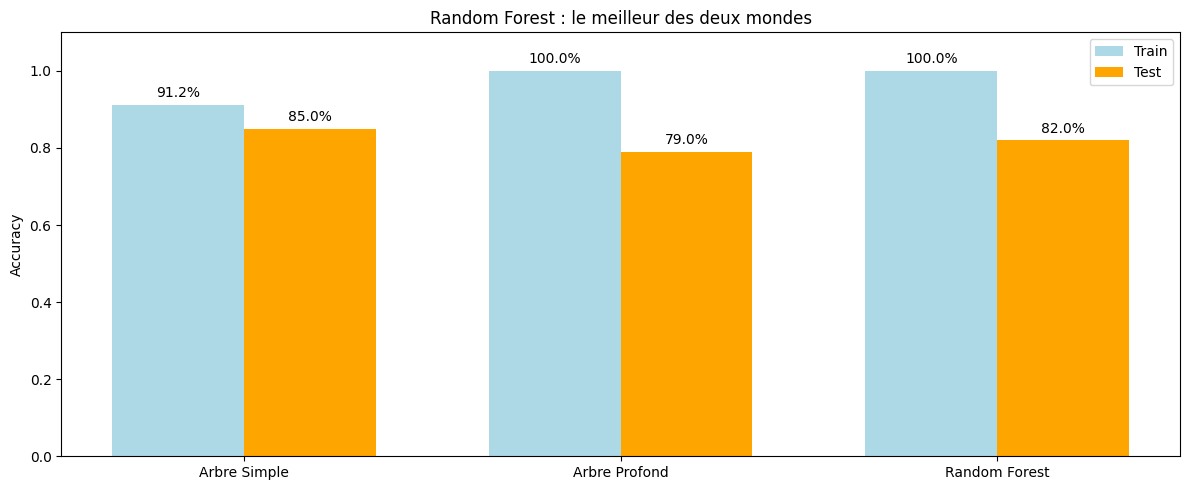

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Entraîner un Random Forest
foret = RandomForestClassifier(n_estimators=100, random_state=42)
foret.fit(X_train, y_train)

# Comparer les trois modèles
modeles = {
    'Arbre Simple (depth=3)': arbre_simple,
    'Arbre Profond (unlimited)': arbre_profond,
    'Random Forest (100 arbres)': foret
}

print("\n" + "═" * 60)
print("COMPARAISON DES MODÈLES")
print("═" * 60)

resultats = []
for nom, model in modeles.items():
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    gap = train_score - test_score
    resultats.append({'Modèle': nom, 'Train': train_score, 'Test': test_score, 'Gap': gap})
    print(f"\n{nom}:")
    print(f"  Train: {train_score:.1%} | Test: {test_score:.1%} | Gap: {gap:.1%}")

print("\n" + "═" * 60)

# Visualisation
df_res = pd.DataFrame(resultats)

plt.figure(figsize=(12, 5))
x = np.arange(len(df_res))
width = 0.35

plt.bar(x - width/2, df_res['Train'], width, label='Train', color='lightblue')
plt.bar(x + width/2, df_res['Test'], width, label='Test', color='orange')

plt.ylabel('Accuracy')
plt.title('Random Forest : le meilleur des deux mondes')
plt.xticks(x, ['Arbre Simple', 'Arbre Profond', 'Random Forest'])
plt.legend()
plt.ylim(0, 1.1)

for i, row in df_res.iterrows():
    plt.annotate(f"{row['Train']:.1%}", xy=(i - width/2, row['Train'] + 0.02), ha='center')
    plt.annotate(f"{row['Test']:.1%}", xy=(i + width/2, row['Test'] + 0.02), ha='center')

plt.tight_layout()
plt.show()

┌─────────────────────────────────────────────────────────────────────────┐
│ 📖 DÉFINITION : Random Forest (Forêt Aléatoire)                         │
│                                                                         │
│ Le **Random Forest** est un algorithme d'**ensemble** qui combine       │
│ les prédictions de nombreux arbres de décision indépendants.            │
│                                                                         │
│ Principes clés :                                                        │
│ • **Bagging** : Chaque arbre est entraîné sur un échantillon bootstrap  │
│   (tirage avec remise) des données                                      │
│ • **Feature randomness** : Chaque split ne considère qu'un sous-ensemble│
│   aléatoire des features                                                │
│ • **Agrégation** : Classification = vote majoritaire, Régression = moyenne│
│                                                                         │
│ Avantages :                                                             │
│ • Réduit l'overfitting des arbres individuels                          │
│ • Robuste au bruit                                                      │
│ • Fournit une mesure d'importance des features                          │
└─────────────────────────────────────────────────────────────────────────┘

---

## 3.6 Feature Importance : Quelles Variables Comptent ?

Un avantage majeur du Random Forest : il peut dire quelles features sont les plus importantes pour la prédiction.


══════════════════════════════════════════════════
IMPORTANCE DES FEATURES (Random Forest)
══════════════════════════════════════════════════
  ratio_dette          : 35.3% █████████████████
  revenu               : 24.5% ████████████
  historique_credit    : 19.4% █████████
  montant_pret         : 10.9% █████
  anciennete_emploi    : 9.9% ████


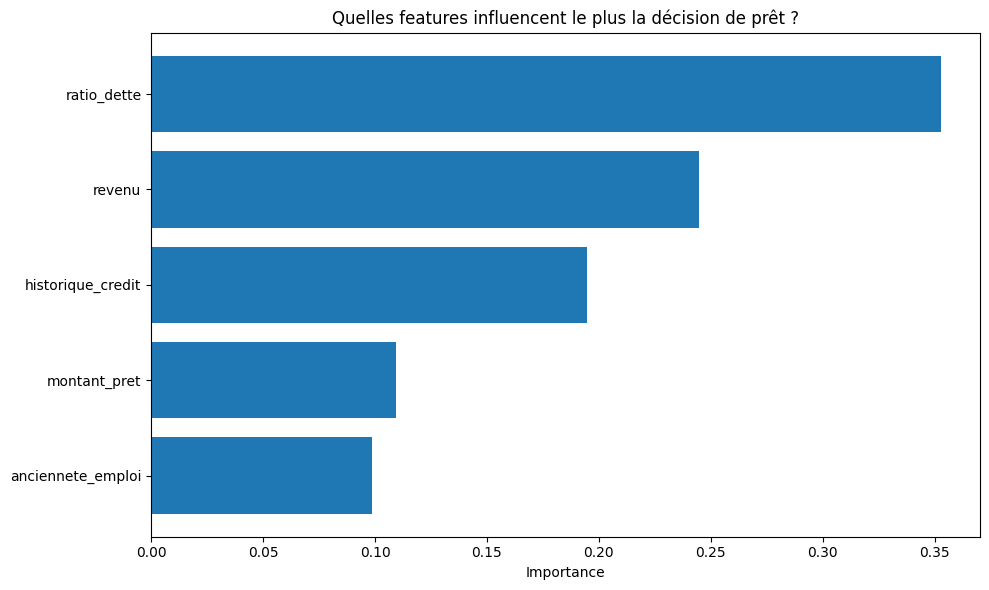

In [18]:
# Extraire l'importance des features
importances = foret.feature_importances_
indices = np.argsort(importances)[::-1]

# Afficher
print("\n" + "═" * 50)
print("IMPORTANCE DES FEATURES (Random Forest)")
print("═" * 50)

for i, idx in enumerate(indices):
    bars = "█" * int(importances[idx] * 50)
    print(f"  {X.columns[idx]:20s} : {importances[idx]:.1%} {bars}")

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), X.columns[indices])
plt.xlabel('Importance')
plt.title('Quelles features influencent le plus la décision de prêt ?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Question :** Ces résultats correspondent-ils à votre intuition sur ce qui devrait être important pour un prêt ?

*(Réponse attendue : Oui ! L'historique de crédit et le revenu sont logiquement les facteurs les plus importants. C'est cohérent avec les pratiques bancaires.)*

---

## 🧪 Exercice Pratique : Classifier les passagers du Titanic

Un classique du ML : prédire qui a survécu au naufrage du Titanic.

In [19]:
# Charger les données Titanic (version simplifiée)
from sklearn.datasets import fetch_openml

# Créer un dataset Titanic simplifié
np.random.seed(42)
n = 800

titanic = pd.DataFrame({
    'classe': np.random.choice([1, 2, 3], n, p=[0.2, 0.3, 0.5]),
    'age': np.random.uniform(1, 80, n),
    'sexe': np.random.choice([0, 1], n),  # 0=homme, 1=femme
    'famille_a_bord': np.random.randint(0, 6, n),
    'tarif': np.random.uniform(5, 500, n)
})

# Simuler la survie (femmes et enfants d'abord, 1ère classe privilégiée)
survie_proba = (
    0.3 * (titanic['sexe'] == 1) +  # Femmes
    0.2 * (titanic['age'] < 15) +    # Enfants
    0.2 * (titanic['classe'] == 1) + # 1ère classe
    0.1 * (titanic['classe'] == 2) + # 2ème classe
    0.1
)
titanic['survie'] = (np.random.random(n) < survie_proba).astype(int)

print("Aperçu des données Titanic :")
display(titanic.head(10))
print(f"\nTaux de survie : {titanic['survie'].mean():.1%}")

Aperçu des données Titanic :
   classe        age  sexe  famille_a_bord       tarif  survie
0       2  56.871852     0               3  403.196418       0
1       3  13.050584     0               2  142.986137       0
2       3  46.526780     1               3  109.298957       0
3       3  48.930489     0               5  478.936769       0
4       1  34.506323     0               1    9.387326       1
5       1  59.179095     1               5  498.921324       0
6       1  74.814994     0               1  340.026543       0
7       3  74.119913     0               0  415.092303       0
8       3  36.616310     1               4  150.836601       1
9       3   9.945806     0               5   12.086062       1

Taux de survie : 37.1%


### Votre mission :

1. Séparez les données en train/test (80/20)
2. Entraînez un arbre de décision (max_depth=5) et un Random Forest (100 arbres)
3. Comparez les performances sur le test set
4. Affichez l'importance des features du Random Forest
5. Interprétez : quel facteur était le plus déterminant pour la survie ?

In [20]:
# 🎯 À VOUS DE JOUER !

# Préparer les données
X_titanic = titanic.drop('survie', axis=1)
y_titanic = titanic['survie']

# Étape 1 : Split
# ...

# Étape 2 : Entraîner arbre et forêt
# ...

# Étape 3 : Comparer performances
# ...

# Étape 4 : Feature importance
# ...

## 🔑 Réponse à l'exercice

In [ ]:
# Solution

# Préparer les données
X_titanic = titanic.drop('survie', axis=1)
y_titanic = titanic['survie']

In [ ]:
# Étape 1 : Split
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42
)

In [ ]:
# Étape 2 : Entraîner
arbre_titanic = DecisionTreeClassifier(max_depth=5, random_state=42)
arbre_titanic.fit(X_train_t, y_train_t)

foret_titanic = RandomForestClassifier(n_estimators=100, random_state=42)
foret_titanic.fit(X_train_t, y_train_t)

In [ ]:
# Étape 3 : Comparer
print("\n" + "═" * 50)
print("RÉSULTATS SUR LE TITANIC")
print("═" * 50)
print(f"\nArbre de décision : {arbre_titanic.score(X_test_t, y_test_t):.1%}")
print(f"Random Forest      : {foret_titanic.score(X_test_t, y_test_t):.1%}")

In [21]:
# Étape 4 : Feature importance
print("\n" + "═" * 50)
print("IMPORTANCE DES FEATURES (pour la survie)")
print("═" * 50)

importance_df = pd.DataFrame({
    'Feature': X_titanic.columns,
    'Importance': foret_titanic.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in importance_df.iterrows():
    print(f"  {row['Feature']:15s} : {row['Importance']:.1%}")

print("\n💡 Interprétation : Le sexe (femmes d'abord)\n"
      "   était déterminants pour la survie")


══════════════════════════════════════════════════
RÉSULTATS SUR LE TITANIC
══════════════════════════════════════════════════

Arbre de décision : 73.1%
Random Forest      : 72.5%

══════════════════════════════════════════════════
IMPORTANCE DES FEATURES (pour la survie)
══════════════════════════════════════════════════
  age             : 36.5%
  tarif           : 33.2%
  sexe            : 13.7%
  famille_a_bord  : 10.9%
  classe          : 5.8%

💡 Interprétation : Le sexe (femmes d'abord) et la classe
   étaient déterminants pour la survie, conformément à
   l'histoire réelle du Titanic.


---

## 📚 Récapitulatif

### Ce que vous avez appris :

1. **Arbre de décision** : Série de questions if/else, très interprétable
2. **Gini** : Mesure d'impureté, l'arbre cherche à la minimiser
3. **Overfitting** : Arbre trop profond = mémorisation, pas généralisation
4. **Random Forest** : Beaucoup d'arbres + vote = robuste et performant
5. **Feature importance** : Quelles variables influencent le plus la prédiction

### Code essentiel :

```python
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Arbre de décision (limiter la profondeur !)
arbre = DecisionTreeClassifier(max_depth=5)
arbre.fit(X_train, y_train)
plot_tree(arbre, feature_names=X.columns, filled=True)

# Random Forest (100+ arbres)
foret = RandomForestClassifier(n_estimators=100)
foret.fit(X_train, y_train)

# Importance des features
print(foret.feature_importances_)
```

### Quand utiliser quoi ?

| Situation | Recommandation |
|-----------|----------------|
| Besoin d'expliquer la décision | Arbre simple (max_depth limité) |
| Priorité à la performance | Random Forest |
| Données avec beaucoup de bruit | Random Forest (plus robuste) |
| Identifier les features importantes | Random Forest + feature_importances_ |

### Prochaine partie : K-Means Clustering

Jusqu'ici, on avait des **labels** (spam/non-spam, approuvé/refusé). Et si on n'avait pas de labels ? Comment trouver des groupes naturels dans les données ? C'est le sujet du **clustering** !

---

## 🤔 Réflexion Métacognitive

Avant de passer à la suite :

1. Pouvez-vous expliquer à quelqu'un pourquoi Random Forest est généralement meilleur qu'un seul arbre ?
2. Dans quel contexte préféreriez-vous un arbre simple interprétable à un Random Forest performant ?
3. Que signifie "feature importance" et comment l'utiliseriez-vous en entreprise ?

---

**Sources :**
- [Wiley 2024 - Analyzing the impact of loan features on bank loan prediction using Random Forest](https://onlinelibrary.wiley.com/doi/10.1002/eng2.12707)
- [ACM 2024 - The Application of Random Forest Classification Model in Credit Risk Assessment](https://dl.acm.org/doi/10.1145/3708036.3708173)
- [scikit-learn RandomForestClassifier Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)